In [2]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

In [7]:
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [8]:
print("Shape :", df.shape)

Shape : (1200, 14)


In [9]:
print("\n Columns:")
print(df.columns.tolist())


 Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


In [10]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), in

In [11]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [12]:
print("\nMissing Percentage:")
print((df.isnull().sum()/ len(df) * 100).round(2))


Missing Percentage:
OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64


In [13]:
print("\nStatistical Summary:")
print(df.describe(include="all"))


Statistical Summary:
          OrderID                 Date CustomerID  Product     Quantity  \
count        1200                 1200       1200     1200  1200.000000   
unique       1200                  NaN       1189        7          NaN   
top     ORD200000                  NaN     C98474  Printer          NaN   
freq            1                  NaN          2      181          NaN   
mean          NaN  2024-03-22 16:58:48        NaN      NaN     2.945833   
min           NaN  2023-01-01 00:00:00        NaN      NaN     1.000000   
25%           NaN  2023-08-03 18:00:00        NaN      NaN     2.000000   
50%           NaN  2024-03-23 00:00:00        NaN      NaN     3.000000   
75%           NaN  2024-11-08 12:00:00        NaN      NaN     4.000000   
max           NaN  2025-06-30 00:00:00        NaN      NaN     5.000000   
std           NaN                  NaN        NaN      NaN     1.407557   

          UnitPrice ShippingAddress PaymentMethod OrderStatus TrackingNumber 

In [16]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [17]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric Columns:")
print(numeric_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numeric Columns:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

Categorical Columns
['OrderID', 'Date', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource']


In [20]:
print(df["CouponCode"].value_counts(dropna=False))

print("\nMissing Values:")
print(df["CouponCode"].isnull().sum())

print("\nUnique values:")
print(df["CouponCode"].nunique(dropna=True))

CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64

Missing Values:
309

Unique values:
3


In [22]:
df["CouponMissing"] = df["CouponCode"].isna()

print(df.groupby("CouponMissing")[["Quantity","UnitPrice","ItemsInCart","TotalPrice"]].mean())

               Quantity   UnitPrice  ItemsInCart   TotalPrice
CouponMissing                                                
False          2.911336  360.596835     5.459035  1057.643715
True           3.045307  344.347961     5.559871  1043.370259


In [24]:
print(pd.crosstab(
     df["ReferralSource"],
     df["CouponCode"],
     normalize="index").round(2))

CouponCode      FREESHIP  SAVE10  WINTER15
ReferralSource                            
Email               0.35    0.31      0.34
Facebook            0.38    0.29      0.34
Google              0.33    0.38      0.29
Instagram           0.37    0.29      0.34
Referral            0.33    0.35      0.33


In [26]:
print("CouponCode vs PaymentMethod")
print(pd.crosstab(
    df["PaymentMethod"],
    df["CouponCode"],
    normalize="index"
).round(2))

print('\n' + '='*50 + '\n')

print("CouponCode vs OrderStatus")
print(pd.crosstab(
    df["OrderStatus"],
    df["CouponCode"],
    normalize="index"
).round(2))

print('\n' + '='*50 + '\n')

print("CouponCode vs Product")
print(pd.crosstab(
    df["Product"],
    df["CouponCode"],
    normalize="index"
).round(2))

print('\n' + '='*50 + '\n')

CouponCode vs PaymentMethod
CouponCode     FREESHIP  SAVE10  WINTER15
PaymentMethod                            
Cash               0.34    0.34      0.31
Credit Card        0.35    0.33      0.32
Debit Card         0.33    0.34      0.33
Gift Card          0.40    0.28      0.33
Online             0.33    0.31      0.35


CouponCode vs OrderStatus
CouponCode   FREESHIP  SAVE10  WINTER15
OrderStatus                            
Cancelled        0.35    0.30      0.35
Delivered        0.34    0.35      0.31
Pending          0.35    0.35      0.30
Returned         0.36    0.27      0.37
Shipped          0.36    0.33      0.32


CouponCode vs Product
CouponCode  FREESHIP  SAVE10  WINTER15
Product                               
Chair           0.34    0.32      0.35
Desk            0.35    0.27      0.38
Laptop          0.35    0.33      0.31
Monitor         0.32    0.30      0.38
Phone           0.38    0.39      0.23
Printer         0.36    0.36      0.28
Tablet          0.36    0.28      

In [29]:
print(df["CouponCode"].isna().sum())
print(df["CouponCode"].value_counts(dropna=False))

309
CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64


In [31]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [34]:
print(df["CouponCode"].value_counts())

print("\n Missing values after treatment :")
print(df["CouponCode"].isna().sum())

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

 Missing values after treatment :
0


In [35]:
for column in numeric_columns:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    print(f"\nColumn: {column}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {len(outliers)}")


Column: Quantity
Q1: 2.0
Q3: 4.0
IQR: 2.0
Lower Bound: -1.0
Upper Bound: 7.0
Number of Outliers: 0

Column: UnitPrice
Q1: 186.0625
Q3: 521.5699999999999
IQR: 335.50749999999994
Lower Bound: -317.1987499999999
Upper Bound: 1024.8312499999997
Number of Outliers: 0

Column: ItemsInCart
Q1: 4.0
Q3: 7.0
IQR: 3.0
Lower Bound: -0.5
Upper Bound: 11.5
Number of Outliers: 0

Column: TotalPrice
Q1: 410.52
Q3: 1578.475
IQR: 1167.955
Lower Bound: -1341.4125
Upper Bound: 3330.4075
Number of Outliers: 8


In [36]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

totalprice_outliers = df[
    (df["TotalPrice"] < lower_bound) |
    (df["TotalPrice"] > upper_bound)
]

print(totalprice_outliers[
    ["OrderID", "Product", "Quantity", "UnitPrice", "TotalPrice"]
])

        OrderID  Product  Quantity  UnitPrice  TotalPrice
107   ORD200107  Printer         5     670.75     3353.75
326   ORD200326   Laptop         5     670.48     3352.40
328   ORD200328   Tablet         5     674.04     3370.20
469   ORD200469    Chair         5     676.98     3384.90
632   ORD200632   Laptop         5     678.16     3390.80
789   ORD200789   Tablet         5     691.28     3456.40
1065  ORD201065  Printer         5     666.80     3334.00
1122  ORD201122  Monitor         5     678.19     3390.95


In [37]:
calculated_total = df["Quantity"] * df["UnitPrice"]

print(
    "All TotalPrice values are correct:",
    np.isclose(df["TotalPrice"], calculated_total).all()
)

All TotalPrice values are correct: True


In [39]:
df["Date"] = pd.to_datetime(df["Date"])

In [41]:
df["OrderYear"] = df["Date"].dt.year

In [42]:
print(df[["Date", "OrderYear"]].head())

        Date  OrderYear
0 2023-01-04       2023
1 2024-08-23       2024
2 2024-02-27       2024
3 2023-10-15       2023
4 2025-05-08       2025


In [43]:
df["OrderMonth"] = df["Date"].dt.month

In [44]:
print(df[["Date", "OrderMonth"]].head())

        Date  OrderMonth
0 2023-01-04           1
1 2024-08-23           8
2 2024-02-27           2
3 2023-10-15          10
4 2025-05-08           5


In [48]:
df["HasCoupon"] = (df["CouponCode"] != "No Coupon").astype(int)

In [49]:
print(df[["CouponCode", "HasCoupon"]].head(10))

  CouponCode  HasCoupon
0     SAVE10          1
1     SAVE10          1
2   FREESHIP          1
3     SAVE10          1
4     SAVE10          1
5     SAVE10          1
6     SAVE10          1
7   FREESHIP          1
8  No Coupon          0
9     SAVE10          1


In [50]:
print(df[[
    "Date",
    "CouponCode",
    "OrderYear",
    "OrderMonth",
    "HasCoupon"
]].head(10))

        Date CouponCode  OrderYear  OrderMonth  HasCoupon
0 2023-01-04     SAVE10       2023           1          1
1 2024-08-23     SAVE10       2024           8          1
2 2024-02-27   FREESHIP       2024           2          1
3 2023-10-15     SAVE10       2023          10          1
4 2025-05-08     SAVE10       2025           5          1
5 2023-10-23     SAVE10       2023          10          1
6 2025-06-17     SAVE10       2025           6          1
7 2023-05-12   FREESHIP       2023           5          1
8 2025-04-02  No Coupon       2025           4          0
9 2023-11-21     SAVE10       2023          11          1


In [51]:
print(df["TotalPrice"].describe())

q1 = df["TotalPrice"].quantile(0.25)
q3 = df["TotalPrice"].quantile(0.75)

print("\nQ1:", q1)
print("Q3:", q3)

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64

Q1: 410.52
Q3: 1578.475


In [52]:
df["OrderValueCategory"] = pd.cut(
    df["TotalPrice"],
    bins = [-np.inf, q1, q3, np.inf],
    labels = ["Low Value", "Medium Value","High Value"]
)

In [55]:
print(df[["TotalPrice", "OrderValueCategory"]])

      TotalPrice OrderValueCategory
0        2853.10         High Value
1         302.70          Low Value
2        2753.40         High Value
3         273.19          Low Value
4        2504.04         High Value
...          ...                ...
1195      107.04          Low Value
1196     1325.06       Medium Value
1197      873.68       Medium Value
1198     1050.08       Medium Value
1199     2242.32         High Value

[1200 rows x 2 columns]


In [56]:
print("\nOrder Value Category Distribution:")
print(df["OrderValueCategory"].value_counts())


Order Value Category Distribution:
OrderValueCategory
Medium Value    599
Low Value       301
High Value      300
Name: count, dtype: int64


In [57]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   OrderID             1200 non-null   str           
 1   Date                1200 non-null   datetime64[us]
 2   CustomerID          1200 non-null   str           
 3   Product             1200 non-null   str           
 4   Quantity            1200 non-null   int64         
 5   UnitPrice           1200 non-null   float64       
 6   ShippingAddress     1200 non-null   str           
 7   PaymentMethod       1200 non-null   str           
 8   OrderStatus         1200 non-null   str           
 9   TrackingNumber      1200 non-null   str           
 10  ItemsInCart         1200 non-null   int64         
 11  CouponCode          1200 non-null   str           
 12  ReferralSource      1200 non-null   str           
 13  TotalPrice          1200 non-null   float64       
 14  Cou

In [58]:
print(df["CouponMissing"].value_counts())
print(df["HasCoupon"].value_counts())

CouponMissing
False    891
True     309
Name: count, dtype: int64
HasCoupon
1    891
0    309
Name: count, dtype: int64


In [59]:
df.drop("CouponMissing", axis=1, inplace=True)

In [60]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   OrderID             1200 non-null   str           
 1   Date                1200 non-null   datetime64[us]
 2   CustomerID          1200 non-null   str           
 3   Product             1200 non-null   str           
 4   Quantity            1200 non-null   int64         
 5   UnitPrice           1200 non-null   float64       
 6   ShippingAddress     1200 non-null   str           
 7   PaymentMethod       1200 non-null   str           
 8   OrderStatus         1200 non-null   str           
 9   TrackingNumber      1200 non-null   str           
 10  ItemsInCart         1200 non-null   int64         
 11  CouponCode          1200 non-null   str           
 12  ReferralSource      1200 non-null   str           
 13  TotalPrice          1200 non-null   float64       
 14  Ord

In [61]:
categorical_columns = [
    "Product",
    "PaymentMethod",
    "OrderStatus",
    "CouponCode",
    "ReferralSource"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())
    print("Unique values:", df[column].nunique())


Product:
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64
Unique values: 7

PaymentMethod:
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64
Unique values: 5

OrderStatus:
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64
Unique values: 5

CouponCode:
CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64
Unique values: 4

ReferralSource:
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64
Unique values: 5


In [62]:
df_encoded = pd.get_dummies(
    df,
    columns = categorical_columns,
    drop_first = False,
    dtype = int
)

In [64]:
print("Original shape:",df.shape)
print("Encoded shape:",df_encoded.shape)

print("\nEncoded columns:")
print(df_encoded.columns.tolist())

Original shape: (1200, 18)
Encoded shape: (1200, 39)

Encoded columns:
['OrderID', 'Date', 'CustomerID', 'Quantity', 'UnitPrice', 'ShippingAddress', 'TrackingNumber', 'ItemsInCart', 'TotalPrice', 'OrderYear', 'OrderMonth', 'HasCoupon', 'OrderValueCategory', 'Product_Chair', 'Product_Desk', 'Product_Laptop', 'Product_Monitor', 'Product_Phone', 'Product_Printer', 'Product_Tablet', 'PaymentMethod_Cash', 'PaymentMethod_Credit Card', 'PaymentMethod_Debit Card', 'PaymentMethod_Gift Card', 'PaymentMethod_Online', 'OrderStatus_Cancelled', 'OrderStatus_Delivered', 'OrderStatus_Pending', 'OrderStatus_Returned', 'OrderStatus_Shipped', 'CouponCode_FREESHIP', 'CouponCode_No Coupon', 'CouponCode_SAVE10', 'CouponCode_WINTER15', 'ReferralSource_Email', 'ReferralSource_Facebook', 'ReferralSource_Google', 'ReferralSource_Instagram', 'ReferralSource_Referral']


In [66]:
print("First 5 rows:")
print(df_encoded.head())

First 5 rows:
     OrderID       Date CustomerID  Quantity  UnitPrice ShippingAddress  \
0  ORD200000 2023-01-04     C72649         5     570.62     928 Main St   
1  ORD200001 2024-08-23     C75739         2     151.35     823 Main St   
2  ORD200002 2024-02-27     C81728         5     550.68     512 Main St   
3  ORD200003 2023-10-15     C33540         1     273.19     275 Main St   
4  ORD200004 2025-05-08     C81840         4     626.01     668 Main St   

  TrackingNumber  ItemsInCart  TotalPrice  OrderYear  ...  \
0    TRK37947903            7     2853.10       2023  ...   
1    TRK91186779            3      302.70       2024  ...   
2    TRK42903982            8     2753.40       2024  ...   
3    TRK62788070            5      273.19       2023  ...   
4    TRK29241424            8     2504.04       2025  ...   

   OrderStatus_Shipped  CouponCode_FREESHIP CouponCode_No Coupon  \
0                    1                    0                    0   
1                    1          

In [67]:
print(df_encoded.dtypes.value_counts())

int64             29
str                4
float64            2
int32              2
datetime64[us]     1
category           1
Name: count, dtype: int64


In [68]:
numeric_columns = df_encoded.select_dtypes(
    include=["int64","int32","float64"]
).columns

print(numeric_columns.tolist())

['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'OrderYear', 'OrderMonth', 'HasCoupon', 'Product_Chair', 'Product_Desk', 'Product_Laptop', 'Product_Monitor', 'Product_Phone', 'Product_Printer', 'Product_Tablet', 'PaymentMethod_Cash', 'PaymentMethod_Credit Card', 'PaymentMethod_Debit Card', 'PaymentMethod_Gift Card', 'PaymentMethod_Online', 'OrderStatus_Cancelled', 'OrderStatus_Delivered', 'OrderStatus_Pending', 'OrderStatus_Returned', 'OrderStatus_Shipped', 'CouponCode_FREESHIP', 'CouponCode_No Coupon', 'CouponCode_SAVE10', 'CouponCode_WINTER15', 'ReferralSource_Email', 'ReferralSource_Facebook', 'ReferralSource_Google', 'ReferralSource_Instagram', 'ReferralSource_Referral']


In [70]:
correlation_matrix = df_encoded[numeric_columns].corr()
print(correlation_matrix)

                           Quantity  UnitPrice  ItemsInCart  TotalPrice  \
Quantity                   1.000000   0.014553     0.650061    0.615251   
UnitPrice                  0.014553   1.000000     0.000602    0.717081   
ItemsInCart                0.650061   0.000602     1.000000    0.392540   
TotalPrice                 0.615251   0.717081     0.392540    1.000000   
OrderYear                 -0.033229  -0.002233    -0.050464   -0.036174   
OrderMonth                -0.015118  -0.026130    -0.018151   -0.027734   
HasCoupon                 -0.041636   0.036048    -0.019329    0.007616   
Product_Chair              0.062726  -0.001593     0.054137    0.022927   
Product_Desk               0.012244  -0.055251     0.016291   -0.034161   
Product_Laptop             0.042780   0.002695    -0.025903    0.028341   
Product_Monitor           -0.000295   0.004528     0.012737    0.011440   
Product_Phone             -0.085505   0.036881    -0.069155   -0.038390   
Product_Printer          

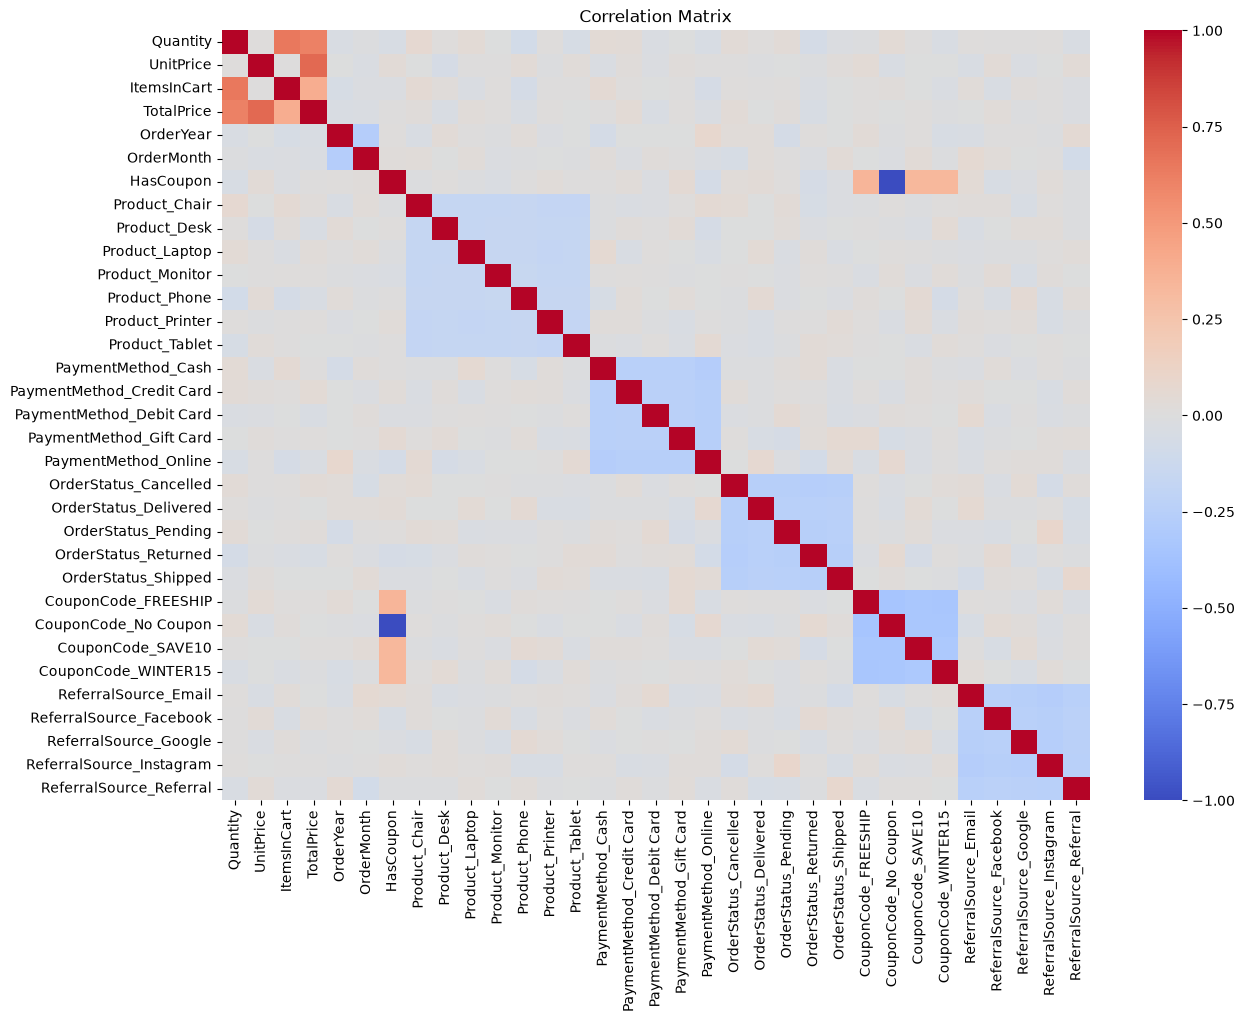

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize=(14,10))
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [74]:
abs_corr = correlation_matrix.abs()

abs_pairs = (
    abs_corr
    .where(~np.eye(abs_corr.shape[0], dtype=bool))
    .stack()
    .sort_values(ascending=False)
)

print(abs_pairs.head(20))

HasCoupon             CouponCode_No Coupon    1.000000
CouponCode_No Coupon  HasCoupon               1.000000
UnitPrice             TotalPrice              0.717081
TotalPrice            UnitPrice               0.717081
ItemsInCart           Quantity                0.650061
Quantity              ItemsInCart             0.650061
TotalPrice            Quantity                0.615251
Quantity              TotalPrice              0.615251
TotalPrice            ItemsInCart             0.392540
ItemsInCart           TotalPrice              0.392540
HasCoupon             CouponCode_FREESHIP     0.349825
CouponCode_FREESHIP   HasCoupon               0.349825
                      CouponCode_No Coupon    0.349825
CouponCode_No Coupon  CouponCode_FREESHIP     0.349825
CouponCode_FREESHIP   CouponCode_WINTER15     0.336867
CouponCode_WINTER15   CouponCode_FREESHIP     0.336867
                      HasCoupon               0.333956
HasCoupon             CouponCode_WINTER15     0.333956
CouponCode

In [78]:
vif_columns = df_encoded.select_dtypes(
    include=["int64", "int32", "float64"]
).columns.tolist()

print(vif_columns)

['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'OrderYear', 'OrderMonth', 'HasCoupon', 'Product_Chair', 'Product_Desk', 'Product_Laptop', 'Product_Monitor', 'Product_Phone', 'Product_Printer', 'Product_Tablet', 'PaymentMethod_Cash', 'PaymentMethod_Credit Card', 'PaymentMethod_Debit Card', 'PaymentMethod_Gift Card', 'PaymentMethod_Online', 'OrderStatus_Cancelled', 'OrderStatus_Delivered', 'OrderStatus_Pending', 'OrderStatus_Returned', 'OrderStatus_Shipped', 'CouponCode_FREESHIP', 'CouponCode_No Coupon', 'CouponCode_SAVE10', 'CouponCode_WINTER15', 'ReferralSource_Email', 'ReferralSource_Facebook', 'ReferralSource_Google', 'ReferralSource_Instagram', 'ReferralSource_Referral']


In [79]:
vif_columns.remove("CouponCode_No Coupon")

In [80]:
print(vif_columns)

['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'OrderYear', 'OrderMonth', 'HasCoupon', 'Product_Chair', 'Product_Desk', 'Product_Laptop', 'Product_Monitor', 'Product_Phone', 'Product_Printer', 'Product_Tablet', 'PaymentMethod_Cash', 'PaymentMethod_Credit Card', 'PaymentMethod_Debit Card', 'PaymentMethod_Gift Card', 'PaymentMethod_Online', 'OrderStatus_Cancelled', 'OrderStatus_Delivered', 'OrderStatus_Pending', 'OrderStatus_Returned', 'OrderStatus_Shipped', 'CouponCode_FREESHIP', 'CouponCode_SAVE10', 'CouponCode_WINTER15', 'ReferralSource_Email', 'ReferralSource_Facebook', 'ReferralSource_Google', 'ReferralSource_Instagram', 'ReferralSource_Referral']


In [81]:
vif_df = df_encoded[vif_columns].copy()

In [82]:
vif_df = vif_df.drop(columns=[
    "Product_Tablet",
    "PaymentMethod_Online",
    "OrderStatus_Shipped",
    "CouponCode_WINTER15",
    "ReferralSource_Referral",
    "HasCoupon"
])

In [83]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()

vif_data["Feature"] = vif_df.columns

vif_data["VIF"] = [
    variance_inflation_factor(vif_df.values, i)
    for i in range(vif_df.shape[1])
]

print(vif_data)

                      Feature        VIF
0                    Quantity  26.206395
1                   UnitPrice  22.496713
2                 ItemsInCart  11.924511
3                  TotalPrice  22.422075
4                   OrderYear  44.609241
5                  OrderMonth   4.293841
6               Product_Chair   2.026850
7                Product_Desk   1.980326
8              Product_Laptop   2.006674
9             Product_Monitor   1.923884
10              Product_Phone   1.905802
11            Product_Printer   2.031033
12         PaymentMethod_Cash   2.002014
13  PaymentMethod_Credit Card   1.949753
14   PaymentMethod_Debit Card   1.937445
15    PaymentMethod_Gift Card   1.936250
16      OrderStatus_Cancelled   2.101830
17      OrderStatus_Delivered   2.035199
18        OrderStatus_Pending   2.063608
19       OrderStatus_Returned   2.090971
20        CouponCode_FREESHIP   1.543761
21          CouponCode_SAVE10   1.505400
22       ReferralSource_Email   2.194892
23    ReferralSo

In [84]:
important_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
    "OrderYear",
    "OrderMonth"
]

print(
    correlation_matrix.loc[
        important_columns,
        important_columns
    ]
)

             Quantity  UnitPrice  ItemsInCart  TotalPrice  OrderYear  \
Quantity     1.000000   0.014553     0.650061    0.615251  -0.033229   
UnitPrice    0.014553   1.000000     0.000602    0.717081  -0.002233   
ItemsInCart  0.650061   0.000602     1.000000    0.392540  -0.050464   
TotalPrice   0.615251   0.717081     0.392540    1.000000  -0.036174   
OrderYear   -0.033229  -0.002233    -0.050464   -0.036174   1.000000   
OrderMonth  -0.015118  -0.026130    -0.018151   -0.027734  -0.269465   

             OrderMonth  
Quantity      -0.015118  
UnitPrice     -0.026130  
ItemsInCart   -0.018151  
TotalPrice    -0.027734  
OrderYear     -0.269465  
OrderMonth     1.000000  


In [85]:
vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)

print(vif_data)

                      Feature        VIF
4                   OrderYear  44.609241
0                    Quantity  26.206395
1                   UnitPrice  22.496713
3                  TotalPrice  22.422075
2                 ItemsInCart  11.924511
5                  OrderMonth   4.293841
25   ReferralSource_Instagram   2.228794
22       ReferralSource_Email   2.194892
24      ReferralSource_Google   2.117106
16      OrderStatus_Cancelled   2.101830
19       OrderStatus_Returned   2.090971
23    ReferralSource_Facebook   2.064565
18        OrderStatus_Pending   2.063608
17      OrderStatus_Delivered   2.035199
11            Product_Printer   2.031033
6               Product_Chair   2.026850
8              Product_Laptop   2.006674
12         PaymentMethod_Cash   2.002014
7                Product_Desk   1.980326
13  PaymentMethod_Credit Card   1.949753
14   PaymentMethod_Debit Card   1.937445
15    PaymentMethod_Gift Card   1.936250
9             Product_Monitor   1.923884
10              

In [86]:
vif_without_year = vif_df.drop(columns=["OrderYear"])

vif_test = pd.DataFrame()

vif_test["Feature"] = vif_without_year.columns

vif_test["VIF"] = [
    variance_inflation_factor(
        vif_without_year.values, i
    )
    for i in range(vif_without_year.shape[1])
]

vif_test = vif_test.sort_values(
    by="VIF",
    ascending=False
)

print(vif_test)

                      Feature        VIF
0                    Quantity  19.935608
3                  TotalPrice  15.294580
1                   UnitPrice  13.422328
2                 ItemsInCart  11.357841
4                  OrderMonth   4.013196
24   ReferralSource_Instagram   2.079425
21       ReferralSource_Email   2.064256
17        OrderStatus_Pending   1.979694
15      OrderStatus_Cancelled   1.975330
23      ReferralSource_Google   1.973838
18       OrderStatus_Returned   1.967983
16      OrderStatus_Delivered   1.949504
11         PaymentMethod_Cash   1.946743
22    ReferralSource_Facebook   1.940381
5               Product_Chair   1.927136
7              Product_Laptop   1.889648
10            Product_Printer   1.883436
12  PaymentMethod_Credit Card   1.882423
13   PaymentMethod_Debit Card   1.869294
14    PaymentMethod_Gift Card   1.865491
6                Product_Desk   1.863101
9               Product_Phone   1.797668
8             Product_Monitor   1.797197
19        Coupon

In [87]:
vif_without_total = vif_df.drop(columns=["TotalPrice"])

vif_test_total = pd.DataFrame()

vif_test_total["Feature"] = vif_without_total.columns

vif_test_total["VIF"] = [
    variance_inflation_factor(
        vif_without_total.values, i
    )
    for i in range(vif_without_total.shape[1])
]

vif_test_total = vif_test_total.sort_values(
    by="VIF",
    ascending=False
)

print(vif_test_total)

                      Feature        VIF
3                   OrderYear  30.428923
2                 ItemsInCart  11.924280
0                    Quantity   9.554144
1                   UnitPrice   4.324527
4                  OrderMonth   4.293816
24   ReferralSource_Instagram   2.223294
21       ReferralSource_Email   2.186154
23      ReferralSource_Google   2.111463
15      OrderStatus_Cancelled   2.099889
18       OrderStatus_Returned   2.090597
17        OrderStatus_Pending   2.063600
22    ReferralSource_Facebook   2.061751
16      OrderStatus_Delivered   2.035196
10            Product_Printer   2.030910
5               Product_Chair   2.023416
7              Product_Laptop   2.006419
11         PaymentMethod_Cash   2.001857
6                Product_Desk   1.979631
12  PaymentMethod_Credit Card   1.948962
13   PaymentMethod_Debit Card   1.937445
14    PaymentMethod_Gift Card   1.936223
8             Product_Monitor   1.923878
9               Product_Phone   1.902814
19        Coupon

In [88]:
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
OrderID               0
Date                  0
CustomerID            0
Product               0
Quantity              0
UnitPrice             0
ShippingAddress       0
PaymentMethod         0
OrderStatus           0
TrackingNumber        0
ItemsInCart           0
CouponCode            0
ReferralSource        0
TotalPrice            0
OrderYear             0
OrderMonth            0
HasCoupon             0
OrderValueCategory    0
dtype: int64


In [89]:
df["TotalPrice_Capped"] = df["TotalPrice"].clip(
    lower=lower_bound,
    upper=upper_bound
)

In [90]:
print(df[["TotalPrice", "TotalPrice_Capped"]].tail(10))

      TotalPrice  TotalPrice_Capped
1190     1849.17            1849.17
1191     1505.72            1505.72
1192     1298.55            1298.55
1193      687.89             687.89
1194      568.32             568.32
1195      107.04             107.04
1196     1325.06            1325.06
1197      873.68             873.68
1198     1050.08            1050.08
1199     2242.32            2242.32


In [91]:
print(
    df.loc[
        df["TotalPrice"] > upper_bound,
        ["OrderID", "TotalPrice", "TotalPrice_Capped"]
    ]
)

        OrderID  TotalPrice  TotalPrice_Capped
107   ORD200107     3353.75          3330.4075
326   ORD200326     3352.40          3330.4075
328   ORD200328     3370.20          3330.4075
469   ORD200469     3384.90          3330.4075
632   ORD200632     3390.80          3330.4075
789   ORD200789     3456.40          3330.4075
1065  ORD201065     3334.00          3330.4075
1122  ORD201122     3390.95          3330.4075


In [92]:
print("Outliers before capping:",
      (df["TotalPrice"] > upper_bound).sum())

print("Values above upper bound after capping:",
      (df["TotalPrice_Capped"] > upper_bound).sum())

Outliers before capping: 8
Values above upper bound after capping: 0


In [93]:
feature_columns = [
    "OrderYear",
    "OrderMonth",
    "HasCoupon",
    "OrderValueCategory"
]

print(df[feature_columns].head())

   OrderYear  OrderMonth  HasCoupon OrderValueCategory
0       2023           1          1         High Value
1       2024           8          1          Low Value
2       2024           2          1         High Value
3       2023          10          1          Low Value
4       2025           5          1         High Value


In [94]:
print("Final Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nData Types:")
print(df.dtypes)

print("\nEngineered Features:")
print([
    "OrderYear",
    "OrderMonth",
    "HasCoupon",
    "OrderValueCategory",
    "TotalPrice_Capped"
])

Final Dataset Shape:
(1200, 19)

Missing Values:
0

Data Types:
OrderID                          str
Date                  datetime64[us]
CustomerID                       str
Product                          str
Quantity                       int64
UnitPrice                    float64
ShippingAddress                  str
PaymentMethod                    str
OrderStatus                      str
TrackingNumber                   str
ItemsInCart                    int64
CouponCode                       str
ReferralSource                   str
TotalPrice                   float64
OrderYear                      int32
OrderMonth                     int32
HasCoupon                      int64
OrderValueCategory          category
TotalPrice_Capped            float64
dtype: object

Engineered Features:
['OrderYear', 'OrderMonth', 'HasCoupon', 'OrderValueCategory', 'TotalPrice_Capped']


In [95]:
df.to_excel("final_cleaned_dataset.xlsx", index=False)

print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!


In [96]:
print(df[[
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]].describe())

          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000


In [97]:
print(df["TotalPrice_Capped"].describe())

count    1200.000000
mean     1053.643183
std       818.937858
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3330.407500
Name: TotalPrice_Capped, dtype: float64


In [98]:
product_sales = df.groupby("Product")["TotalPrice"].sum().sort_values(
    ascending=False
)

print(product_sales)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64
